# Dimensionality Reduction — PCA and SVD

*Part of the ML Course Reference Series.*

## Q30: What is PCA (Principal Component Analysis)?

PCA finds the directions (principal components) of maximum variance in the data and projects data onto them. It:

1. **Reduces dimensionality** — keep top K components instead of all features
2. **Removes correlated features** — components are orthogonal by construction
3. **Helps visualisation** — project to 2D to see clusters

`explained_variance_ratio_` tells you how much variance each component captures.

Explained variance ratio: [0.443 0.19 ]
Together: 63.2% of variance


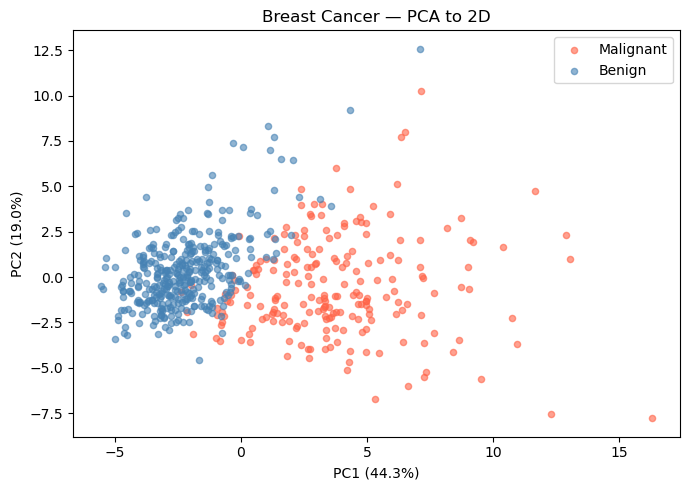

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))
print(f'Together: {pca.explained_variance_ratio_.sum():.1%} of variance')

plt.figure(figsize=(7, 5))
for cls, color, label in [(0, 'tomato', 'Malignant'), (1, 'steelblue', 'Benign')]:
    mask = y_cancer == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Breast Cancer — PCA to 2D')
plt.legend()
plt.tight_layout()
plt.show()

## Q30b: What is SVD (Singular Value Decomposition)?

SVD decomposes any matrix **M** (m×n) into three matrices:

```
M = U · Σ · Vᵀ
```

| Matrix | Shape | Meaning |
|---|---|---|
| **U** | m×m | Left singular vectors — directions in row space |
| **Σ** | m×n | Diagonal — singular values (importance of each direction) |
| **Vᵀ** | n×n | Right singular vectors — directions in column space |

**Truncated SVD:** keep only the top K singular values → best rank-K approximation of M (minimum Frobenius error).

**Relation to PCA:** PCA is SVD applied to the mean-centred, scaled data matrix. The principal components are the columns of V.

M shape: (4, 3)
U: (4, 4)   Σ: (4, 3)   Vᵀ: (3, 3)
Singular values: [25.462  1.291  0.   ]
Reconstruction error: 0.0

Rank-K approximation error (Frobenius norm):
  K=1: 1.2907
  K=2: 0.0000
  K=3: 0.0000


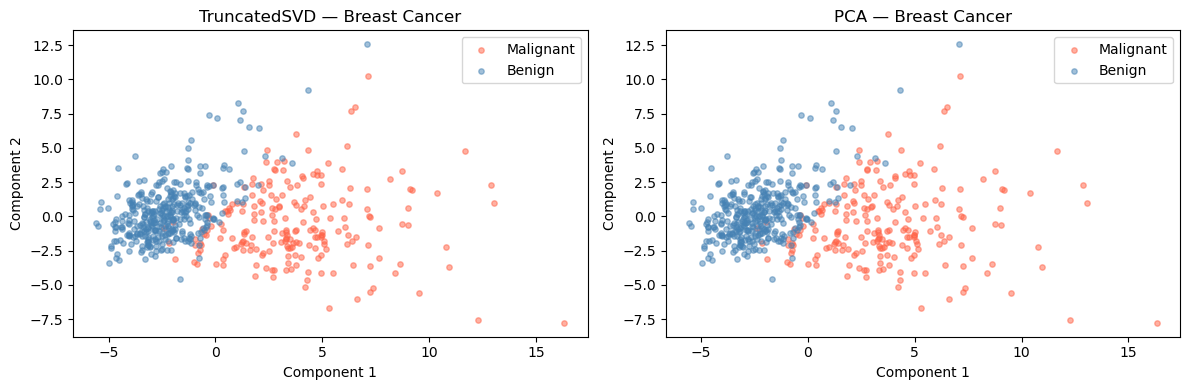

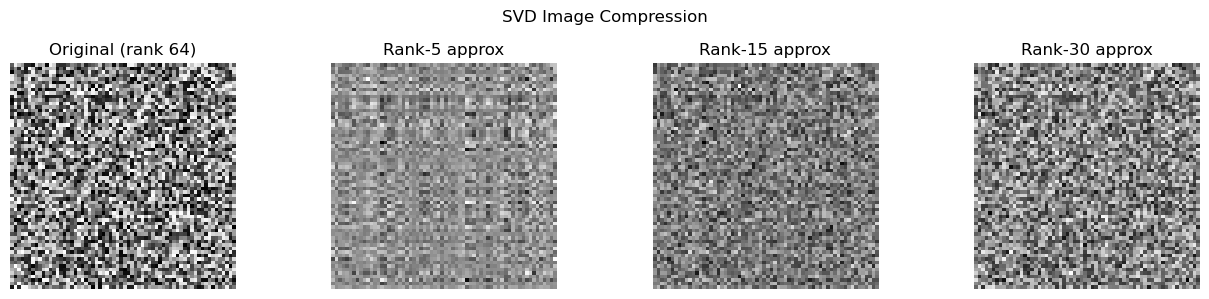

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ── 1. Full SVD ──────────────────────────────────────────────────────────────
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]], dtype=float)

U, s, Vt = np.linalg.svd(M, full_matrices=True)
Sigma = np.zeros(M.shape)
np.fill_diagonal(Sigma, s)

print('M shape:', M.shape)
print('U:', U.shape, '  Σ:', Sigma.shape, '  Vᵀ:', Vt.shape)
print('Singular values:', s.round(3))
print('Reconstruction error:', np.linalg.norm(M - U @ Sigma @ Vt).round(10))

# ── 2. Truncated SVD — rank-K approximation ───────────────────────────────────
print('\nRank-K approximation error (Frobenius norm):')
for k in [1, 2, 3]:
    M_approx = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    err = np.linalg.norm(M - M_approx)
    print(f'  K={k}: {err:.4f}')

# ── 3. SVD for dimensionality reduction (vs PCA) ──────────────────────────────
from sklearn.decomposition import TruncatedSVD, PCA

X_scaled = StandardScaler().fit_transform(X_cancer)

# Both should give nearly identical 2-D projections
svd_proj = TruncatedSVD(n_components=2, random_state=42).fit_transform(X_scaled)
pca_proj = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, proj, title in [(axes[0], svd_proj, 'TruncatedSVD'),
                         (axes[1], pca_proj, 'PCA')]:
    for cls, color, label in [(0, 'tomato', 'Malignant'), (1, 'steelblue', 'Benign')]:
        mask = y_cancer == cls
        ax.scatter(proj[mask, 0], proj[mask, 1], c=color, label=label, alpha=0.5, s=15)
    ax.set_title(f'{title} — Breast Cancer')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend()
plt.tight_layout()
plt.show()

# ── 4. Image compression via SVD ─────────────────────────────────────────────
np.random.seed(42)
img = np.random.rand(64, 64)   # synthetic 64×64 "image"
U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (rank 64)')

for ax, k in zip(axes[1:], [5, 15, 30]):
    approx = U_img[:, :k] @ np.diag(s_img[:k]) @ Vt_img[:k, :]
    ax.imshow(approx, cmap='gray')
    ax.set_title(f'Rank-{k} approx')
for ax in axes:
    ax.axis('off')
plt.suptitle('SVD Image Compression')
plt.tight_layout()
plt.show()